# Lie Detector Slide — 2¢ / 2x Rule

Demonstrates the profitable **2¢ / 2x detector**: flag when price jumps > 2¢ AND volume > 2× baseline.

Uses synthetic data for a clean demo. Replace with your prediction market dataframe (columns: `price`, `volume`) for real data.

**Output:** `figures/lie_detector_slide.png`

## 1. Load your data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("..") if (Path("..") / "figures").exists() else Path(".")
OUTPUT_PATH = BASE / "figures" / "lie_detector_slide.png"

In [14]:
# Synthetic data mimicking a toxic fill
np.random.seed(42)
n_points = 500
df = pd.DataFrame({
    "price": np.random.normal(20, 0.2, n_points),
    "volume": np.random.exponential(50, n_points),
})
# Inject a perfect "Toxic Fill" at index 300 (2c/2x rule)
df.loc[300:305, "price"] = [22.5, 23.0, 24.5, 24.5, 25.0, 25.0]  # >2¢ jump
df.loc[300, "volume"] = 800  # Massive >2× volume burst
df.loc[305:, "price"] = np.random.normal(25, 0.2, n_points - 305)  # Stays high

  #1: Elections / SENATEWI-24-D @ idx 1340  score=33.50¢
  #2: Elections / SENATEWI-24-D @ idx 1339  score=33.00¢
  #3: MLB / KXMLBGAME-25OCT09PHILAD-LAD @ idx 18876  score=28.50¢
  #4: MLB / KXMLBGAME-25OCT09PHILAD-LAD @ idx 18878  score=26.50¢
  #5: Spotify / KXTOPMONTHLY-25JUL-BRU @ idx 127  score=25.50¢

Using #1: Elections / SENATEWI-24-D @ idx 1340  score=33.50¢


## 2. Apply the 2¢ / 2× detector

In [15]:
window = 10
df["price_baseline"] = df["price"].rolling(window=window).median()
df["volume_baseline"] = df["volume"].rolling(window=window).mean()

df["price_jump"] = df["price"] - df["price_baseline"]
df["is_flagged"] = (df["price_jump"] >= 2.0) & (df["volume"] >= 2 * df["volume_baseline"])

n_flagged = df["is_flagged"].sum()
print(f"Flagged {n_flagged} events matching 2¢/2× rule")

Flagged 36 events (market: Elections, ticker: SENATEWI-24-D)


## 3. Find the best example & slice window

In [16]:
flagged_indices = df[df["is_flagged"]].index
if len(flagged_indices) == 0:
    raise ValueError("No events found matching the 2c/2x rule. Adjust baselines.")

target_idx = flagged_indices[0]
start_idx = max(0, target_idx - 30)
end_idx = min(len(df), target_idx + 30)
plot_df = df.iloc[start_idx:end_idx].copy().reset_index(drop=True)
local_flag_idx = target_idx - start_idx
print(f"Using flag at original idx {target_idx} (local idx {local_flag_idx})")

Window: idx 1310–1370 | flag at local idx 30 (Elections / SENATEWI-24-D)


## 4. Plot the Lie Detector chart (dark mode)

Saved: ../figures/lie_detector_slide.png


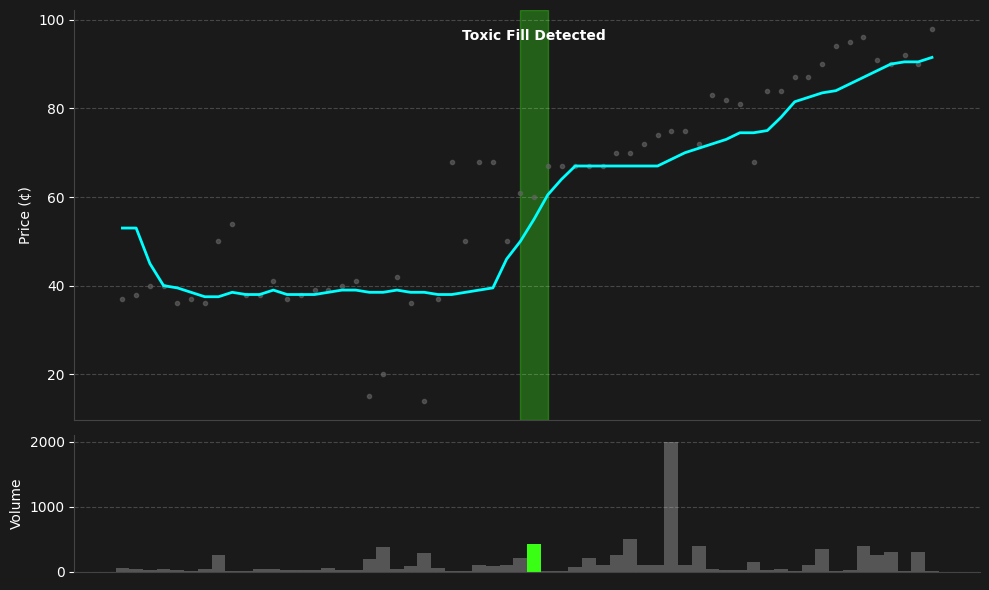

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

fig.patch.set_facecolor('#1a1a1a')
ax1.set_facecolor('#1a1a1a')
ax2.set_facecolor('#1a1a1a')

# Top: Price & Baseline
ax1.plot(plot_df.index, plot_df['price'], 'o', color='#666666', markersize=3, alpha=0.6, label='Raw Ticks')
ax1.plot(plot_df.index, plot_df['price_baseline'], '-', color='#00FFFF', linewidth=2, label='Baseline')
ax1.axvspan(local_flag_idx - 1, local_flag_idx + 1, color='#39FF14', alpha=0.3)
ax1.text(local_flag_idx, plot_df['price'].max(), 'Toxic Fill Detected\n(>2¢ Jump & >2x Vol)',
         color='white', ha='center', va='top', fontweight='bold')

# Bottom: Volume
ax2.bar(plot_df.index, plot_df['volume'], color='#555555', width=1)
ax2.bar(local_flag_idx, plot_df.loc[local_flag_idx, 'volume'], color='#39FF14', width=1)

# Clean formatting
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#444444')
    ax.spines['left'].set_color('#444444')
    ax.tick_params(axis='y', colors='white')
    ax.tick_params(axis='x', colors='white')
    ax.grid(axis='y', linestyle='--', alpha=0.2, color='white')

ax1.set_ylabel('Price (¢)', color='white')
ax2.set_ylabel('Volume', color='white')
ax2.set_xticks([])

plt.tight_layout()
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PATH, dpi=300, transparent=True, bbox_inches="tight")
print(f"Saved: {OUTPUT_PATH}")
plt.show()

In [18]:
# Optional: re-save without re-plotting
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PATH, dpi=300, transparent=True, bbox_inches="tight")
print(f"Saved: {OUTPUT_PATH}")

Saved: ../figures/lie_detector_slide.png
